In [107]:
# All required imports to run this file are stored here
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [108]:
# Read in the relevant csv files, store them as pd dataframes
all_vuln_df = pd.read_csv("../data/checklist_data_cleaned.csv")
covered_vuln_df = pd.read_csv("../data/specific_data_cleaned.csv")
own_app_vuln_df = pd.read_csv("../data/own_coverage_data_cleaned.csv")

# Display them both to check
display(all_vuln_df)
display(covered_vuln_df)
display(own_app_vuln_df)

,Category,Vulnerability
0,STORAGE,MASWE-0001: Insertion of Sensitive Data into Logs
1,STORAGE,MASWE-0002: Sensitive Data Stored With Insuffi...
2,STORAGE,MASWE-0003: Backup Unencrypted
3,STORAGE,MASWE-0004: Sensitive Data Not Excluded From B...
4,STORAGE,MASWE-0006: Sensitive Data Stored Unencrypted ...
...,...,...
112,PRIVACY,MASWE-0112: Inadequate Data Collection Declara...
113,PRIVACY,MASWE-0113: Lack of Proper Data Management Con...
114,PRIVACY,MASWE-0114: Inadequate Data Visibility Controls
115,PRIVACY,MASWE-0115: Inadequate or Ambiguous User Conse...


,App Name,MASVS Category,Vulnerability,MASVS Counterpart
0,Androgoat,Storage,Insecure Data Storage – Shared Prefs - 1,MASWE-0006: Sensitive Data Stored Unencrypted ...
1,Androgoat,Storage,Insecure Data Storage - Shared Prefs - 2,MASWE-0006: Sensitive Data Stored Unencrypted ...
2,Androgoat,Storage,Insecure Data Storage - SQLite,MASWE-0006: Sensitive Data Stored Unencrypted ...
3,Androgoat,Storage,Insecure Data Storage – Temp Files,MASWE-0006: Sensitive Data Stored Unencrypted ...
4,Androgoat,Storage,Insecure Data Storage – SD Card,MASWE-0007: Sensitive Data Stored Unencrypted ...
...,...,...,...,...
158,BugBazaar,Code,Runtime code modification,MASWE-0085: Unsafe Dynamic Code Loading
159,BugBazaar,Code,Improper cache handling,MASWE-0082 Unsafe Handling of Data from Local ...
160,BugBazaar,Resilience,Passcode Bypass,MASWE-0008: Missing Device Secure Lock Verific...
161,BugBazaar,Resilience,Debuggable application,MASWE-0067: Debuggable Flag Not Disabled


,Category,Vulnerability
0,STORAGE,MASWE-0001: Insertion of Sensitive Data into Logs
1,STORAGE,MASWE-0002: Sensitive Data Stored With Insuffi...
2,STORAGE,MASWE-0003: Backup Unencrypted
3,STORAGE,MASWE-0004: Sensitive Data Not Excluded From B...
4,STORAGE,MASWE-0006: Sensitive Data Stored Unencrypted ...
5,STORAGE,MASWE-0007: Sensitive Data Stored Unencrypted ...
6,CRYPTO,MASWE-0009: Improper Cryptographic Key Generation
7,CRYPTO,MASWE-0010: Improper Cryptographic Key Derivation
8,CRYPTO,MASWE-0011: Cryptographic Key Rotation Not Imp...
9,CRYPTO,MASWE-0012: Insecure or Wrong Usage of Cryptog...


In [109]:
# --- Count coverage frequency ---
coverage_count = (
    covered_vuln_df.groupby("MASVS Counterpart")
    .size()
    .reset_index(name="Coverage Count")
)

# Add corresponding col to own coverage df
own_app_vuln_df["Coverage"] = 1
display(own_app_vuln_df)

,Category,Vulnerability,Coverage
0,STORAGE,MASWE-0001: Insertion of Sensitive Data into Logs,1
1,STORAGE,MASWE-0002: Sensitive Data Stored With Insuffi...,1
2,STORAGE,MASWE-0003: Backup Unencrypted,1
3,STORAGE,MASWE-0004: Sensitive Data Not Excluded From B...,1
4,STORAGE,MASWE-0006: Sensitive Data Stored Unencrypted ...,1
5,STORAGE,MASWE-0007: Sensitive Data Stored Unencrypted ...,1
6,CRYPTO,MASWE-0009: Improper Cryptographic Key Generation,1
7,CRYPTO,MASWE-0010: Improper Cryptographic Key Derivation,1
8,CRYPTO,MASWE-0011: Cryptographic Key Rotation Not Imp...,1
9,CRYPTO,MASWE-0012: Insecure or Wrong Usage of Cryptog...,1


In [110]:
# --- Merge to see which ones are covered and how often ---
merged_df = all_vuln_df.merge(
    coverage_count,
    left_on="Vulnerability",
    right_on="MASVS Counterpart",
    how="left"
)

display(merged_df)

,Category,Vulnerability,MASVS Counterpart,Coverage Count
0,STORAGE,MASWE-0001: Insertion of Sensitive Data into Logs,MASWE-0001: Insertion of Sensitive Data into Logs,7.0
1,STORAGE,MASWE-0002: Sensitive Data Stored With Insuffi...,NaN,NaN
2,STORAGE,MASWE-0003: Backup Unencrypted,MASWE-0003: Backup Unencrypted,3.0
3,STORAGE,MASWE-0004: Sensitive Data Not Excluded From B...,NaN,NaN
4,STORAGE,MASWE-0006: Sensitive Data Stored Unencrypted ...,MASWE-0006: Sensitive Data Stored Unencrypted ...,14.0
...,...,...,...,...
112,PRIVACY,MASWE-0112: Inadequate Data Collection Declara...,NaN,NaN
113,PRIVACY,MASWE-0113: Lack of Proper Data Management Con...,NaN,NaN
114,PRIVACY,MASWE-0114: Inadequate Data Visibility Controls,NaN,NaN
115,PRIVACY,MASWE-0115: Inadequate or Ambiguous User Conse...,NaN,NaN


In [111]:
merged_df_with_own_app = merged_df.merge(
    own_app_vuln_df,
    left_on="Vulnerability",
    right_on="Vulnerability",
    how="left"
)

display(merged_df_with_own_app)

,Category_x,Vulnerability,MASVS Counterpart,Coverage Count,Category_y,Coverage
0,STORAGE,MASWE-0001: Insertion of Sensitive Data into Logs,MASWE-0001: Insertion of Sensitive Data into Logs,7.0,STORAGE,1.0
1,STORAGE,MASWE-0002: Sensitive Data Stored With Insuffi...,NaN,NaN,STORAGE,1.0
2,STORAGE,MASWE-0003: Backup Unencrypted,MASWE-0003: Backup Unencrypted,3.0,STORAGE,1.0
3,STORAGE,MASWE-0004: Sensitive Data Not Excluded From B...,NaN,NaN,STORAGE,1.0
4,STORAGE,MASWE-0006: Sensitive Data Stored Unencrypted ...,MASWE-0006: Sensitive Data Stored Unencrypted ...,14.0,STORAGE,1.0
...,...,...,...,...,...,...
112,PRIVACY,MASWE-0112: Inadequate Data Collection Declara...,NaN,NaN,NaN,NaN
113,PRIVACY,MASWE-0113: Lack of Proper Data Management Con...,NaN,NaN,NaN,NaN
114,PRIVACY,MASWE-0114: Inadequate Data Visibility Controls,NaN,NaN,NaN,NaN
115,PRIVACY,MASWE-0115: Inadequate or Ambiguous User Conse...,NaN,NaN,NaN,NaN


In [112]:
# Drop the duplicate category
merged_df_with_own_app.drop("Category_y", axis=1, inplace=True)
merged_df_with_own_app.columns = ['Category', 'Vulnerability', 'MASVS Counterpart', 'Coverage Count',
       'Coverage']

# Add own vulnerabilities to the coverage count
#merged_df_with_own_app[merged_df_with_own_app["Coverage Count"].isna()]["Coverage count"] = 0
#merged_df_with_own_app.loc[merged_df_with_own_app["Coverage Count"].isna(), "Coverage Count"] = 0
merged_df_with_own_app["Coverage Count"] = merged_df_with_own_app["Coverage Count"].fillna(0).astype(int)
merged_df_with_own_app["Coverage"] = merged_df_with_own_app["Coverage"].fillna(0).astype(int)

newly_covered_vuln_df = merged_df_with_own_app[(merged_df_with_own_app["Coverage Count"] == 0) & (merged_df_with_own_app["Coverage"] == 1)]


merged_df_with_own_app["Coverage Count"] += merged_df_with_own_app["Coverage"]

# Drop (now) unnecessary Coverage col
#merged_df_with_own_app.drop("Coverage", axis=1, inplace=True)


merged_df_with_own_app

,Category,Vulnerability,MASVS Counterpart,Coverage Count,Coverage
0,STORAGE,MASWE-0001: Insertion of Sensitive Data into Logs,MASWE-0001: Insertion of Sensitive Data into Logs,8,1
1,STORAGE,MASWE-0002: Sensitive Data Stored With Insuffi...,NaN,1,1
2,STORAGE,MASWE-0003: Backup Unencrypted,MASWE-0003: Backup Unencrypted,4,1
3,STORAGE,MASWE-0004: Sensitive Data Not Excluded From B...,NaN,1,1
4,STORAGE,MASWE-0006: Sensitive Data Stored Unencrypted ...,MASWE-0006: Sensitive Data Stored Unencrypted ...,15,1
...,...,...,...,...,...
112,PRIVACY,MASWE-0112: Inadequate Data Collection Declara...,NaN,0,0
113,PRIVACY,MASWE-0113: Lack of Proper Data Management Con...,NaN,0,0
114,PRIVACY,MASWE-0114: Inadequate Data Visibility Controls,NaN,0,0
115,PRIVACY,MASWE-0115: Inadequate or Ambiguous User Conse...,NaN,0,0


In [113]:
# Fill NaN (means no coverage) with 0
#merged_df_with_own_app["Coverage Count"] = merged_df_with_own_app["Coverage Count"].fillna(0).astype(int)

# --- Identify uncovered vulnerabilities ---
uncovered = merged_df_with_own_app[merged_df_with_own_app["Coverage Count"] == 0]

# --- Print results ---
print("=== Coverage summary ===")
print(merged_df_with_own_app[["Vulnerability", "Coverage Count"]])

print("\n=== Uncovered vulnerabilities ===")
print(uncovered["Vulnerability"])
print(len(uncovered))

=== Coverage summary ===
                                         Vulnerability  Coverage Count
0    MASWE-0001: Insertion of Sensitive Data into Logs               8
1    MASWE-0002: Sensitive Data Stored With Insuffi...               1
2                       MASWE-0003: Backup Unencrypted               4
3    MASWE-0004: Sensitive Data Not Excluded From B...               1
4    MASWE-0006: Sensitive Data Stored Unencrypted ...              15
..                                                 ...             ...
112  MASWE-0112: Inadequate Data Collection Declara...               0
113  MASWE-0113: Lack of Proper Data Management Con...               0
114    MASWE-0114: Inadequate Data Visibility Controls               0
115  MASWE-0115: Inadequate or Ambiguous User Conse...               0
116       MASWE-0117: Inadequate Permission Management               0

[117 rows x 2 columns]

=== Uncovered vulnerabilities ===
26     MASWE-0028: MFA Implementation Best Practices ...
27     

In [114]:
# --- Filter only covered vulnerabilities ---
covered_only = merged_df_with_own_app[merged_df_with_own_app["Coverage Count"] > 0]

# --- Sort by coverage count (descending) ---
covered_sorted = covered_only.sort_values(by="Coverage Count", ascending=False)

# --- Display result ---
print("=== Covered vulnerabilities (sorted by coverage count) ===")
print(covered_sorted[["Vulnerability", "Coverage Count"]])
print("There are:", len(covered_sorted[["Vulnerability", "Coverage Count"]]), "covered vulnerabilities.")

=== Covered vulnerabilities (sorted by coverage count) ===
                                         Vulnerability  Coverage Count
64                        MASWE-0066: Insecure Intents              18
4    MASWE-0006: Sensitive Data Stored Unencrypted ...              15
62              MASWE-0064: Insecure Content Providers              10
0    MASWE-0001: Insertion of Sensitive Data into Logs               8
5    MASWE-0007: Sensitive Data Stored Unencrypted ...               8
56                     MASWE-0058: Insecure Deep Links               7
61            MASWE-0063: Insecure Broadcast Receivers               7
51   MASWE-0053: Sensitive Data Leaked via the User...               7
25   MASWE-0005: API Keys Hardcoded in the App Package               6
83             MASWE-0085: Unsafe Dynamic Code Loading               6
84                           MASWE-0086: SQL Injection               6
69   MASWE-0071: WebViews Loading Content from Untr...               5
31   MASWE-0033: A

In [115]:
# mark which vulnerabilities are covered
merged_df_with_own_app["Is_Covered"] = merged_df_with_own_app["Coverage Count"] > 0

display(merged_df_with_own_app)

# group by Category and count totals and covered ones
summary_new = merged_df_with_own_app.groupby("Category").agg(
    total_vulnerabilities=("Vulnerability", "count"),
    covered_vulnerabilities=("Is_Covered", "sum")
)

# optionally, add a coverage percentage
summary_new["coverage_percentage"] = (
    summary_new["covered_vulnerabilities"] / summary_new["total_vulnerabilities"] * 100
).round(1)

# Define the order to reflect maswe order
desired_order = ["STORAGE", "CRYPTO", "AUTH", "NETWORK", "PLATFORM", "CODE", "RESILIENCE", "PRIVACY"]

# Reindex summary
summary_new = summary_new.reindex(desired_order)

print(summary_new)

,Category,Vulnerability,MASVS Counterpart,Coverage Count,Coverage,Is_Covered
0,STORAGE,MASWE-0001: Insertion of Sensitive Data into Logs,MASWE-0001: Insertion of Sensitive Data into Logs,8,1,True
1,STORAGE,MASWE-0002: Sensitive Data Stored With Insuffi...,NaN,1,1,True
2,STORAGE,MASWE-0003: Backup Unencrypted,MASWE-0003: Backup Unencrypted,4,1,True
3,STORAGE,MASWE-0004: Sensitive Data Not Excluded From B...,NaN,1,1,True
4,STORAGE,MASWE-0006: Sensitive Data Stored Unencrypted ...,MASWE-0006: Sensitive Data Stored Unencrypted ...,15,1,True
...,...,...,...,...,...,...
112,PRIVACY,MASWE-0112: Inadequate Data Collection Declara...,NaN,0,0,False
113,PRIVACY,MASWE-0113: Lack of Proper Data Management Con...,NaN,0,0,False
114,PRIVACY,MASWE-0114: Inadequate Data Visibility Controls,NaN,0,0,False
115,PRIVACY,MASWE-0115: Inadequate or Ambiguous User Conse...,NaN,0,0,False


            total_vulnerabilities  covered_vulnerabilities  \
Category                                                     
STORAGE                         6                        6   
CRYPTO                         19                       19   
AUTH                           20                        2   
NETWORK                         6                        3   
PLATFORM                       22                       17   
CODE                           15                        6   
RESILIENCE                     20                        7   
PRIVACY                         9                        0   

            coverage_percentage  
Category                         
STORAGE                   100.0  
CRYPTO                    100.0  
AUTH                       10.0  
NETWORK                    50.0  
PLATFORM                   77.3  
CODE                       40.0  
RESILIENCE                 35.0  
PRIVACY                     0.0  


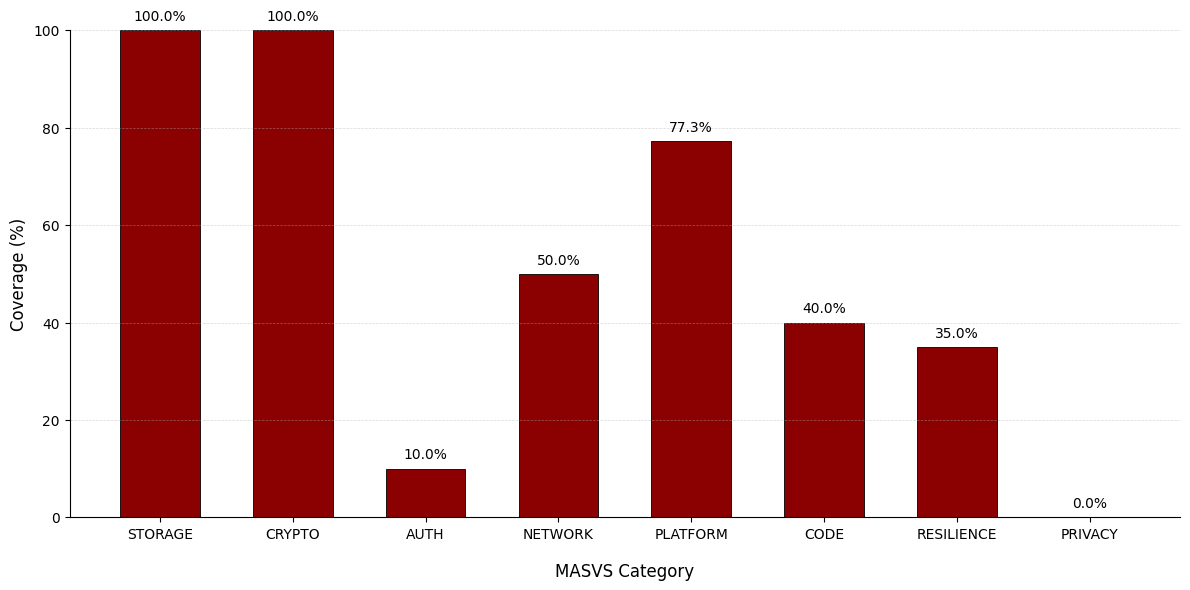

In [116]:
# Explicit style
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the bar chart
ax.bar(summary_new.index, summary_new["coverage_percentage"], color="darkred", 
       width=0.6, edgecolor="black", linewidth=0.6)

# Customize appearance
#ax.set_title("Vulnerability Coverage by MASWE Category", fontsize=14)
ax.set_xlabel("MASVS Category", fontsize=12, labelpad=15)
ax.set_ylabel("Coverage (%)", fontsize=12)
ax.set_ylim(0, 100)
ax.grid(axis="y", linestyle="--", alpha=0.5, linewidth=0.5)
ax.spines[["top", "right"]].set_visible(False)

# Add values on top of each bar
for i, v in enumerate(summary_new["coverage_percentage"]):
    ax.text(i, v + 2, f"{v:.1f}%", ha="center", fontsize=10)

# Show the plot
plt.tight_layout()
plt.show()

# Save the figure
fig.savefig("../plots/total_coverage_with_my_app/vulnerability_coverage_percentage_with_own_app", dpi=300, bbox_inches="tight")

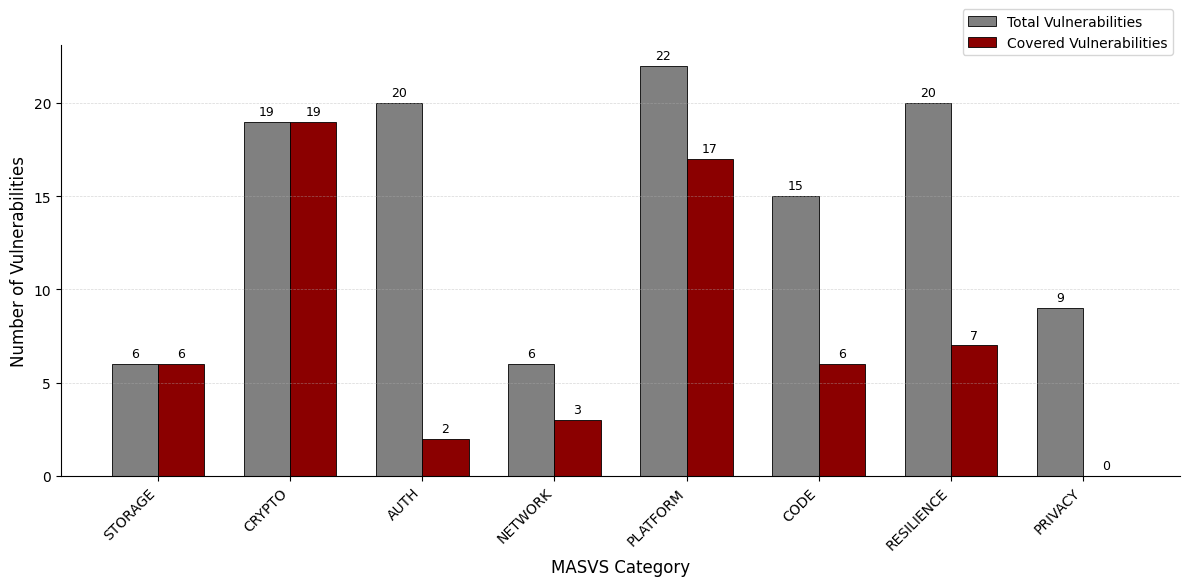

In [117]:
# Prepare data
categories = summary_new.index
total = summary_new["total_vulnerabilities"]
covered = summary_new["covered_vulnerabilities"]

# Set bar positions
x = np.arange(len(categories))
width = 0.35  # width of each bar

# Explicit style plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot both total and covered bars
bars1 = ax.bar(x - width/2, total, width, label="Total Vulnerabilities", color="gray",
               edgecolor="black", linewidth=0.6)
bars2 = ax.bar(x + width/2, covered, width, label="Covered Vulnerabilities", color="darkred",
               edgecolor="black", linewidth=0.6)

# Customize plot
#ax.set_title("Vulnerability Coverage (Counts)", fontsize=14)
ax.set_xlabel("MASVS Category", fontsize=12)
ax.set_ylabel("Number of Vulnerabilities", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45, ha="right")
ax.legend(
    loc="upper right",          # position relative to the Axes
    bbox_to_anchor=(1, 1.1),  # (x, y) — 1.15 moves it a bit above the top
    frameon=True                # optional: remove box background
)
ax.grid(axis="y", linestyle="--", alpha=0.5, linewidth=0.5)
ax.spines[["top", "right"]].set_visible(False)

# Annotate bars with values
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.2,
                f"{int(height)}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

# Save the figure
fig.savefig("../plots/total_coverage_with_my_app/total_vs_implemented_vulnerability_counts_with_own_app", dpi=300, bbox_inches="tight")

In [118]:
# Generate the old summary here

# --- Count coverage frequency ---
coverage_count = (
    covered_vuln_df.groupby("MASVS Counterpart")
    .size()
    .reset_index(name="Coverage Count")
)


# --- Merge to see which ones are covered and how often ---
merged_df = all_vuln_df.merge(
    coverage_count,
    left_on="Vulnerability",
    right_on="MASVS Counterpart",
    how="left"
)

display(merged_df)

# Fill NaN (means no coverage) with 0
merged_df["Coverage Count"] = merged_df["Coverage Count"].fillna(0).astype(int)

# --- Identify uncovered vulnerabilities ---
uncovered = merged_df[merged_df["Coverage Count"] == 0]

# --- Print results ---
print("=== Coverage summary ===")
print(merged_df[["Vulnerability", "Coverage Count"]])

print("\n=== Uncovered vulnerabilities ===")
print(uncovered["Vulnerability"])

# --- Filter only covered vulnerabilities ---
covered_only = merged_df[merged_df["Coverage Count"] > 0]

# --- Sort by coverage count (descending) ---
covered_sorted = covered_only.sort_values(by="Coverage Count", ascending=False)

# --- Display result ---
print("=== Covered vulnerabilities (sorted by coverage count) ===")
print(covered_sorted[["Vulnerability", "Coverage Count"]])
print("There are:", len(covered_sorted[["Vulnerability", "Coverage Count"]]), "covered vulnerabilities.")

# mark which vulnerabilities are covered
merged_df["Is_Covered"] = merged_df["Coverage Count"] > 0

display(merged_df)

# group by Category and count totals and covered ones
summary_old = merged_df.groupby("Category").agg(
    total_vulnerabilities=("Vulnerability", "count"),
    covered_vulnerabilities=("Is_Covered", "sum")
)

# optionally, add a coverage percentage
summary_old["coverage_percentage"] = (
    summary_old["covered_vulnerabilities"] / summary_old["total_vulnerabilities"] * 100
).round(1)

# Define the order to reflect maswe order
desired_order = ["STORAGE", "CRYPTO", "AUTH", "NETWORK", "PLATFORM", "CODE", "RESILIENCE", "PRIVACY"]

# Reindex summary
summary_old = summary_old.reindex(desired_order)

print(summary_old)

,Category,Vulnerability,MASVS Counterpart,Coverage Count
0,STORAGE,MASWE-0001: Insertion of Sensitive Data into Logs,MASWE-0001: Insertion of Sensitive Data into Logs,7.0
1,STORAGE,MASWE-0002: Sensitive Data Stored With Insuffi...,NaN,NaN
2,STORAGE,MASWE-0003: Backup Unencrypted,MASWE-0003: Backup Unencrypted,3.0
3,STORAGE,MASWE-0004: Sensitive Data Not Excluded From B...,NaN,NaN
4,STORAGE,MASWE-0006: Sensitive Data Stored Unencrypted ...,MASWE-0006: Sensitive Data Stored Unencrypted ...,14.0
...,...,...,...,...
112,PRIVACY,MASWE-0112: Inadequate Data Collection Declara...,NaN,NaN
113,PRIVACY,MASWE-0113: Lack of Proper Data Management Con...,NaN,NaN
114,PRIVACY,MASWE-0114: Inadequate Data Visibility Controls,NaN,NaN
115,PRIVACY,MASWE-0115: Inadequate or Ambiguous User Conse...,NaN,NaN


=== Coverage summary ===
                                         Vulnerability  Coverage Count
0    MASWE-0001: Insertion of Sensitive Data into Logs               7
1    MASWE-0002: Sensitive Data Stored With Insuffi...               0
2                       MASWE-0003: Backup Unencrypted               3
3    MASWE-0004: Sensitive Data Not Excluded From B...               0
4    MASWE-0006: Sensitive Data Stored Unencrypted ...              14
..                                                 ...             ...
112  MASWE-0112: Inadequate Data Collection Declara...               0
113  MASWE-0113: Lack of Proper Data Management Con...               0
114    MASWE-0114: Inadequate Data Visibility Controls               0
115  MASWE-0115: Inadequate or Ambiguous User Conse...               0
116       MASWE-0117: Inadequate Permission Management               0

[117 rows x 2 columns]

=== Uncovered vulnerabilities ===
1      MASWE-0002: Sensitive Data Stored With Insuffi...
3      

,Category,Vulnerability,MASVS Counterpart,Coverage Count,Is_Covered
0,STORAGE,MASWE-0001: Insertion of Sensitive Data into Logs,MASWE-0001: Insertion of Sensitive Data into Logs,7,True
1,STORAGE,MASWE-0002: Sensitive Data Stored With Insuffi...,NaN,0,False
2,STORAGE,MASWE-0003: Backup Unencrypted,MASWE-0003: Backup Unencrypted,3,True
3,STORAGE,MASWE-0004: Sensitive Data Not Excluded From B...,NaN,0,False
4,STORAGE,MASWE-0006: Sensitive Data Stored Unencrypted ...,MASWE-0006: Sensitive Data Stored Unencrypted ...,14,True
...,...,...,...,...,...
112,PRIVACY,MASWE-0112: Inadequate Data Collection Declara...,NaN,0,False
113,PRIVACY,MASWE-0113: Lack of Proper Data Management Con...,NaN,0,False
114,PRIVACY,MASWE-0114: Inadequate Data Visibility Controls,NaN,0,False
115,PRIVACY,MASWE-0115: Inadequate or Ambiguous User Conse...,NaN,0,False


            total_vulnerabilities  covered_vulnerabilities  \
Category                                                     
STORAGE                         6                        4   
CRYPTO                         19                        4   
AUTH                           20                        2   
NETWORK                         6                        3   
PLATFORM                       22                       16   
CODE                           15                        6   
RESILIENCE                     20                        7   
PRIVACY                         9                        0   

            coverage_percentage  
Category                         
STORAGE                    66.7  
CRYPTO                     21.1  
AUTH                       10.0  
NETWORK                    50.0  
PLATFORM                   72.7  
CODE                       40.0  
RESILIENCE                 35.0  
PRIVACY                     0.0  


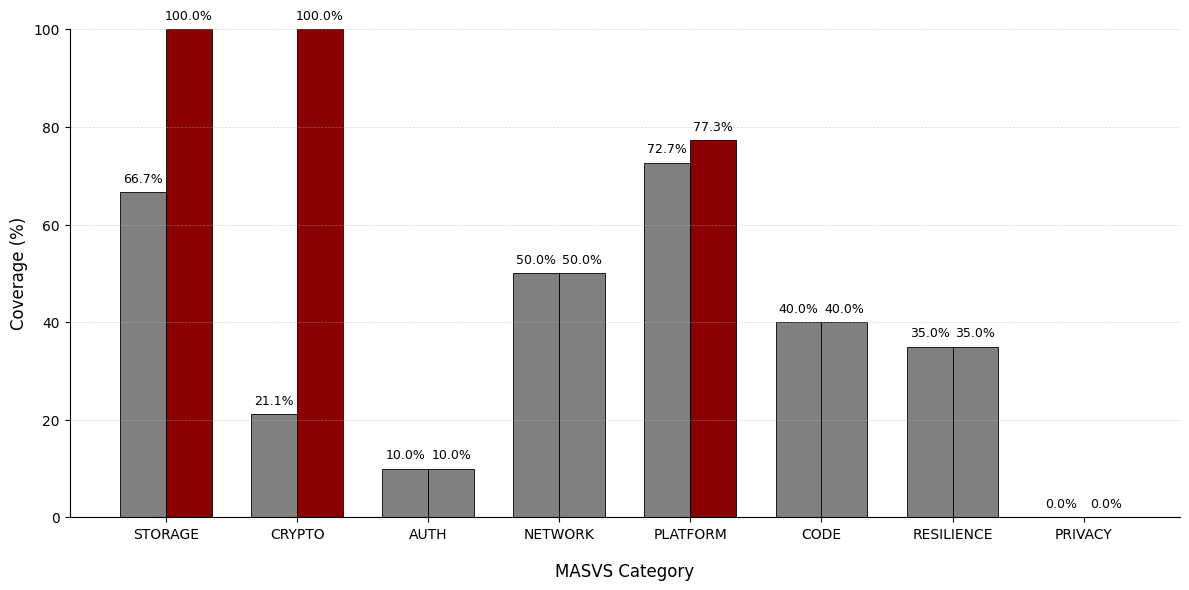

In [119]:
# Plot both old and new summary in same graph for nice comparison
# Explicit style
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare positions for side-by-side bars
x = np.arange(len(summary_old.index))
width = 0.35

# Define which categories should be darkred
highlight_categories = ["storage", "crypto", "platform"]

# Create color arrays based on category names
colors_bars2 = ["darkred" if cat.lower() in highlight_categories else "gray" 
                for cat in summary_old.index]

# Plot the bar chart side-by-side
bars1 = ax.bar(x - width/2, summary_old["coverage_percentage"], width,
               color="gray", edgecolor="black", linewidth=0.6, 
               label="Without our apps")
bars2 = ax.bar(x + width/2, summary_new["coverage_percentage"], width,
               color=colors_bars2, edgecolor="black", linewidth=0.6, 
               label="With our apps")

# Customize appearance
#ax.set_title("Vulnerability Coverage by MASWE Category", fontsize=14)
ax.set_xlabel("MASVS Category", fontsize=12, labelpad=15)
ax.set_ylabel("Coverage (%)", fontsize=12)
ax.set_ylim(0, 100)
ax.set_xticks(x)
ax.set_xticklabels(summary_old.index)
#ax.legend(loc="upper right", bbox_to_anchor=(1, 1.1), frameon=True)
ax.grid(axis="y", linestyle="--", alpha=0.5, linewidth=0.5)
ax.spines[["top", "right"]].set_visible(False)

# Add values on top of each bar
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 2,
            f"{height:.1f}%", ha="center", fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 2,
            f"{height:.1f}%", ha="center", fontsize=9)

# Show the plot
plt.tight_layout()
plt.show()

# Save the figure
fig.savefig("../plots/total_coverage_with_my_app/vulnerability_coverage_percentage_comparison.png", dpi=300, bbox_inches="tight")

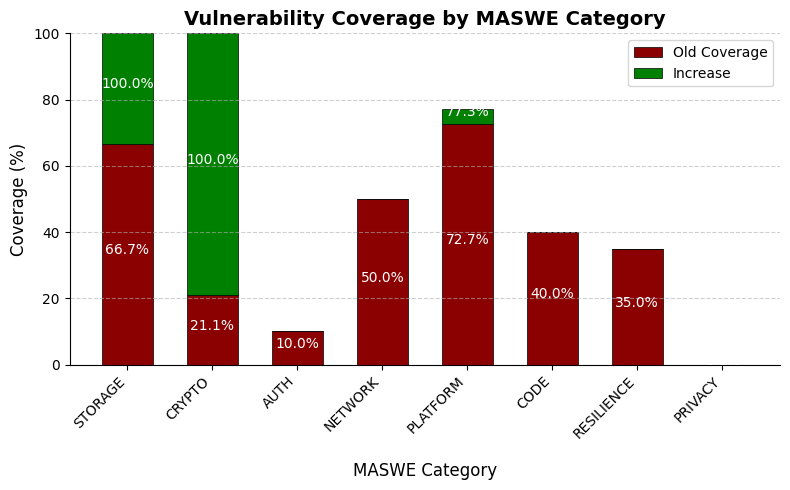

In [120]:
import matplotlib.pyplot as plt
import numpy as np

# Example: summary_old and summary_new Series
# summary_old["coverage_percentage"], summary_new["coverage_percentage"]

x = np.arange(len(summary_new.index))  # x positions
old_vals = summary_old["coverage_percentage"]
new_vals = summary_new["coverage_percentage"]

# Calculate only the increase (clip at 0 so we don't plot negative)
increase = (new_vals - old_vals).clip(lower=0)

# Plot old coverage (solid)
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    x,
    old_vals,
    color="darkred",
    width=0.6,
    edgecolor="black",
    linewidth=0.5,
    label="Old Coverage"
)

# Plot only the increase on top
ax.bar(
    x,
    increase,
    bottom=old_vals,  # stack it on top of old values
    color="green",
    width=0.6,
    edgecolor="black",
    linewidth=0.5,
    label="Increase"
)

# Customize appearance
ax.set_title("Vulnerability Coverage by MASWE Category", fontsize=14, weight='bold')
ax.set_xlabel("MASWE Category", fontsize=12, labelpad=15)
ax.set_ylabel("Coverage (%)", fontsize=12)
ax.set_ylim(0, 100)
ax.set_xticks(x)
ax.set_xticklabels(summary_new.index, rotation=45, ha="right")
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.spines[["top", "right"]].set_visible(False)
ax.legend()

# Annotate bars: show old and new values
for i, (old_v, inc_v) in enumerate(zip(old_vals, increase)):
    ax.text(i, old_v / 2, f"{old_v:.1f}%", ha="center", fontsize=10, color="white")  # old value inside old bar
    if inc_v > 0:
        ax.text(i, old_v + inc_v / 2, f"{old_v + inc_v:.1f}%", ha="center", fontsize=10, color="white")  # new part

plt.tight_layout()
plt.show()

# Save figure
fig.savefig("../plots/vulnerability_coverage_progress_ugly", dpi=300, bbox_inches="tight")
